In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy.linalg
import scipy.stats as stats

from sklearn.decomposition import PCA

import torch

from tqdm.auto import tqdm

from transformers import GPT2Model, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [64]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2-xl")

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

# Import text and tokenize

In [65]:
# generated by Claude.ai
sentences = [
    "I saw him at the market.",
    "She gave him the book.",
    "They asked him for advice.",
    "We invited him to dinner.",
    "The dog followed him home.",
    "They asked him to join.",
    "He saw him at the park yesterday.",
    "Did you give him your address?",
    "I haven't seen him in ages.",
    "I told him the truth.",
    "They congratulated him on his success.",
    "She recognized him immediately.",
    "The teacher praised him for his work.",
    "I met him last summer.",
    "The child hugged him tightly.",
    "They warned him about the danger.",
    "She drove him to the airport.",
    "We waited for him for hours.",
    "The cat scratched him accidentally.",
    "They surprised him with a gift.",
    "She called him on the phone.",
    "The jury found him not guilty.",
    "I remembered him from school.",
    "They elected him as president.",
    "She forgave him for his mistake.",
    "The police questioned him yesterday.",
    "I helped him with his homework.",
    "They spotted him in the crowd.",
    "She visited him in the hospital.",
    "The manager promoted him last week.",
    "I trusted him completely.",
    "They respected him for his honesty.",
    "She taught him how to swim.",
    "The bird attacked him suddenly.",
    "I greeted him warmly.",
    "They supported him through difficult times.",
    "She ignored him at the party.",
    "The judge sentenced him to community service.",
    "I photographed him during the event.",
    "They believed him despite the evidence.",
    "She surprised him on his birthday.",
    "The guard stopped him at the entrance.",
    "I missed him terribly.",
    "They watched him leave the building.",
    "She accompanied him to the concert.",
    "The crowd cheered him enthusiastically.",
    "I described him to the police.",
    "They thanked him for his help.",
    "She admired him for his courage.",
    "The committee nominated him for the award.",
    "I married him last spring.",
    "They informed him about the changes.",
    "She introduced him to the parents.",
    "The author based the character on him.",

## same sentences but with "her"

    "I saw her at the market.",
    "She gave her the book.",
    "They asked her for advice.",
    "We invited her to dinner.",
    "The dog followed her home.",
    "They asked her to join.",
    "He saw her at the park yesterday.",
    "Did you give her your address?",
    "I haven't seen her in ages.",
    "I told her the truth.",
    "They congratulated her on his success.",
    "She recognized her immediately.",
    "The teacher praised her for his work.",
    "I met her last summer.",
    "The child hugged her tightly.",
    "They warned her about the danger.",
    "She drove her to the airport.",
    "We waited for her for hours.",
    "The cat scratched her accidentally.",
    "They surprised her with a gift.",
    "She called her on the phone.",
    "The jury found her not guilty.",
    "I remembered her from school.",
    "They elected her as president.",
    "She forgave her for his mistake.",
    "The police questioned her yesterday.",
    "I helped her with his homework.",
    "They spotted her in the crowd.",
    "She visited her in the hospital.",
    "The manager promoted her last week.",
    "I trusted her completely.",
    "They respected her for his honesty.",
    "She taught her how to swim.",
    "The bird attacked her suddenly.",
    "I greeted her warmly.",
    "They supported her through difficult times.",
    "She ignored her at the party.",
    "The judge sentenced her to community service.",
    "I photographed her during the event.",
    "They believed her despite the evidence.",
    "She surprised her on his birthday.",
    "The guard stopped her at the entrance.",
    "I missed her terribly.",
    "They watched her leave the building.",
    "She accompanied her to the concert.",
    "The crowd cheered her enthusiastically.",
    "I described her to the police.",
    "They thanked her for his help.",
    "She admired her for his courage.",
    "The committee nominated her for the award.",
    "I married her last spring.",
    "They informed her about the changes.",
    "She introduced her to the parents.",
    "The author based the character on her."
]

# indices of him/her sentences
him_sentences = np.arange(len(sentences)//2)
her_sentences = np.arange(len(sentences)//2,len(sentences))

print(f'There are {len(sentences)} sentences.')

There are 108 sentences.


In [66]:
target_token_him = tokenizer.encode(' him')
target_token_her = tokenizer.encode(' her')

print(f'target_token_him: {target_token_him}')
print(f'target_token_her: {target_token_her}')

tokenizer.pad_token = tokenizer.eos_token

# Tokenize the sentences as train dataset
train_tokens = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

target_token_him: [683]
target_token_her: [607]


In [67]:
try:
  from datatrove.pipeline.readers import ParquetReader
except ImportError:
  !pip install datatrove
  from datatrove.pipeline.readers import ParquetReader

numDocs = 2000 # how many documents to retrive; each doc has ~750 tokens
data_reader = ParquetReader('hf://datasets/HuggingFaceFW/fineweb/data',limit=numDocs)

# join all texts into one token vector
tokens = np.array([],dtype=int)
for t in data_reader():
  tokens = np.append(tokens,tokenizer.encode(t.text))


2026-03-17 18:13:57.029 | INFO     | datatrove.pipeline.readers.base:read_files_shard:206 - Reading input file CC-MAIN-2013-20/000_00000.parquet, 1/27468


In [68]:
# find all "him" and "her" tokens
him_tokens = np.where(tokens==target_token_him[0])[0]
her_tokens = np.where(tokens==target_token_her[0])[0]

# Verify
for i in him_tokens[:10]:
  print(tokenizer.decode(tokens[i-5:i+5]))

. The drive would take him through a stretch of
 Skipper Speaker doubled off him with two outs in
 an ailment, left him there with a short
 day would come, for him play on a big
 on something his father gave him. "I was
 How did that bill help him get to this point
 car. Her death leads him on a path back
worthy educator? Nominate him or her!

 demonstrates this as we watch him make 57 failed attempts
 for education in EM make him a perfect fit on


In [69]:
# create a batch
batch = np.zeros((100,10),dtype=int)
for i in range(50):
  batch[i,:] = tokens[him_tokens[i]-5:him_tokens[i]+5]

  # "her" tokens have source index offset to avoid risk of using the same sentence
  batch[50+i,:] = tokens[her_tokens[len(her_tokens)//2+i]-5:her_tokens[len(her_tokens)//2+i]+5]

# create a tokens dictionary
test_tokens = {}
test_tokens['input_ids'] = torch.tensor(batch)
test_tokens['attention_mask'] = torch.ones_like(test_tokens['input_ids'])

test_tokens['input_ids'].shape

torch.Size([100, 10])

In [70]:
# and show a few examples
for i in [16,34,60,90]:
  print(f'Example {i}:',tokenizer.decode(test_tokens['input_ids'][i]))

Example 16:  a better job of keeping him upright. We did
Example 34:  speaker and photographer. Contact him at firstname.
Example 60:  daughter Blue Ivy Carter in her arms and RadarOnline
Example 90: . To a Widow and her Infant 8s


# Implant activations for train and test datasets

In [71]:
# hook function to store MLP attention vectors
activations = {}
def implant_hook_mlp(layer_number):
  def hook(module, input, output):
    activations[f'mlp_{layer_number}'] = output.detach().numpy()
  return hook

# hook it!
numLayers = model.config.n_layer
for layeri in range(numLayers):
  model.h[layeri].mlp.c_fc.register_forward_hook(implant_hook_mlp(layeri))

In [72]:
# TRAIN tokens to define GED vectors
with torch.no_grad(): model(**train_tokens)
train_activations = activations.copy()

# TEST tokens to evaluate out-of-sample performance
with torch.no_grad(): model(**test_tokens)
test_activations = activations.copy()

In [73]:
# confirm dataset sizes
print('Train activations are size:',train_activations['mlp_5'].shape)
print('Test activations are size:',test_activations['mlp_5'].shape)

Train activations are size: (108, 8, 6400)
Test activations are size: (100, 10, 6400)


# PCA Analysis

In [74]:
def pca_reducedim(layeri):
    # Initialize target activations
    d_model = train_activations[f'mlp_{layeri}'].shape[-1]
    trainacts = np.zeros((len(sentences), d_model))

    for senti in range(len(sentences)):
        tokens = train_tokens['input_ids'][senti].numpy()

        # mask for ' him' or ' her'
        target_token_mask = (
            (tokens == target_token_him[0]) |
            (tokens == target_token_her[0])
        )
        target_idx = np.where(target_token_mask)[0]

        if len(target_idx) != 1:
            raise ValueError(
                f"Expected exactly 1 target token in sentence {senti}, got {len(target_idx)}"
            )

        trainacts[senti] = train_activations[f'mlp_{layeri}'][senti, target_idx[0]]

    # PCA
    pca_model = PCA().fit(trainacts)

    pca_eigenvecs = pca_model.components_.T
    pca_variance = 100 * pca_model.explained_variance_ratio_
    pca_variance_cum = np.cumsum(pca_variance)

    n_components = np.where(pca_variance_cum > 99)[0][0]

    return trainacts, pca_eigenvecs, n_components

In [75]:
# Test the function
layeri = 5
trainacts, pca_eigenvecs, n_components = pca_reducedim(layeri)

trainacts.shape, pca_eigenvecs.shape, n_components

((108, 6400), (6400, 108), np.int64(57))

# Generalized Eigen Decomposition (GED)

In [76]:
def sourcesep_GED_train(trainacts, pca_eigvecs, n_components):
    # project to PCA space
    lowD_acts = trainacts @ pca_eigvecs[:, :n_components]

    # covariance matrices
    himProjcov = np.cov(lowD_acts[him_sentences, :].T)
    herProjcov = np.cov(lowD_acts[her_sentences, :].T)

    # regularization
    regu_gam = 0.01
    himProjcovS = (1 - regu_gam) * himProjcov + regu_gam * np.mean(np.linalg.eigvalsh(himProjcov)) * np.eye(n_components)
    herProjcovS = (1 - regu_gam) * herProjcov + regu_gam * np.mean(np.linalg.eigvalsh(herProjcov)) * np.eye(n_components)

    # GED: HIM > HER
    evalsHim, evecsHim = scipy.linalg.eigh(himProjcov, herProjcovS)
    idx = evalsHim.argsort()[::-1]
    evalsHim = np.real(evalsHim[idx])
    evecsHim = np.real(evecsHim[:, idx])

    # GED: HER > HIM
    evalsHer, evecsHer = scipy.linalg.eigh(herProjcov, himProjcovS)
    idx = evalsHer.argsort()[::-1]
    evalsHer = np.real(evalsHer[idx])
    evecsHer = np.real(evecsHer[:, idx])

    # projections
    ged_proj_him = lowD_acts @ evecsHim[:, 0]
    ged_proj_her = lowD_acts @ evecsHer[:, 0]

    # MLP-space patterns
    mlpPattern_him = pca_eigvecs[:, :n_components] @ himProjcov @ evecsHim[:, 0]
    mlpPattern_her = pca_eigvecs[:, :n_components] @ herProjcov @ evecsHer[:, 0]

    r = stats.pearsonr(np.real(mlpPattern_him), np.real(mlpPattern_her))

    return ged_proj_him, ged_proj_her, evecsHim, evecsHer, r, evalsHim[0], evalsHer[0]

# Loop over all layers of the model

In [77]:
ged_results = np.zeros((numLayers, 7, 2))

for layeri in tqdm(range(numLayers), desc='Transformer blocks', leave=False):
    # PCA
    trainacts, PCA_eigvecs, numComps2keep = pca_reducedim(layeri)

    # GED using current layer PCA outputs
    ged_proj_him, ged_proj_her, evecsHim, evecsHer, r, evHim, evHer = sourcesep_GED_train(
        trainacts, PCA_eigvecs, numComps2keep
    )

    # train t-tests
    tres = stats.ttest_ind(ged_proj_him[him_sentences], ged_proj_him[her_sentences])
    ged_results[layeri, 0, 0] = abs(tres.statistic)
    ged_results[layeri, 0, 1] = tres.pvalue

    tres = stats.ttest_ind(ged_proj_her[him_sentences], ged_proj_her[her_sentences])
    ged_results[layeri, 1, 0] = abs(tres.statistic)
    ged_results[layeri, 1, 1] = tres.pvalue

    ged_results[layeri, 2, 0] = abs(r.statistic)
    ged_results[layeri, 2, 1] = r.pvalue

    ged_results[layeri, 5, 0] = evHim
    ged_results[layeri, 5, 1] = evHer
    ged_results[layeri, 6, 0] = numComps2keep

    # test activations
    testacts = test_activations[f'mlp_{layeri}'][:, 5, :]

    # project test data into same PCA space
    actsProj = testacts @ PCA_eigvecs[:, :numComps2keep]

    # project onto GED vectors
    ged_proj_him_test = actsProj @ evecsHim[:, 0]
    ged_proj_her_test = actsProj @ evecsHer[:, 0]

    # out-of-sample t-tests
    tres = stats.ttest_ind(ged_proj_him_test[:50], ged_proj_him_test[50:])
    ged_results[layeri, 3, 0] = abs(tres.statistic)
    ged_results[layeri, 3, 1] = tres.pvalue

    tres = stats.ttest_ind(ged_proj_her_test[:50], ged_proj_her_test[50:])
    ged_results[layeri, 4, 0] = abs(tres.statistic)
    ged_results[layeri, 4, 1] = tres.pvalue

Transformer blocks:   0%|          | 0/48 [00:00<?, ?it/s]

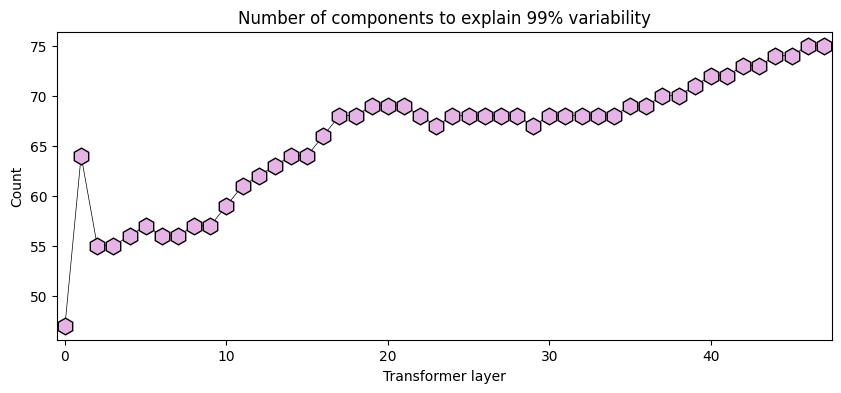

In [78]:
plt.figure(figsize=(10,4))

plt.plot(ged_results[:,6,0],'kh-',markerfacecolor=[.9,.7,.9],linewidth=.5,markersize=12)

plt.gca().set(xlabel='Transformer layer',ylabel='Count',xlim=[-.5,numLayers-.5],
              title='Number of components to explain 99% variability')

plt.show()

# Visualize GED results

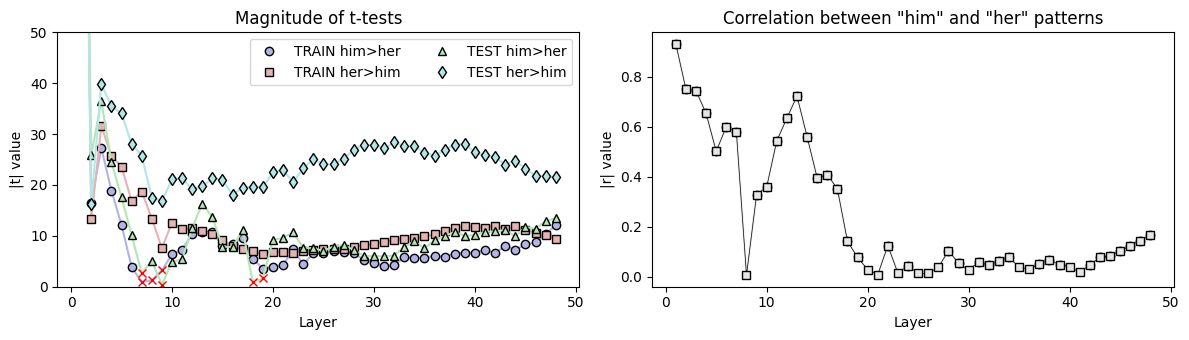

In [79]:
_,axs = plt.subplots(1,2,figsize=(12,3.5))

xtix = np.arange(1,numLayers+1)
pvalthresh = .05/numLayers

# TRAIN him > her
p = ged_results[:,0,1]
axs[0].plot(xtix,ged_results[:,0,0],color=[.7,.7,.9])
axs[0].plot(xtix[p<pvalthresh],ged_results[p<pvalthresh,0,0],'ko',markerfacecolor=[.7,.7,.9],linewidth=.5,label='TRAIN him>her')
axs[0].plot(xtix[p>pvalthresh],ged_results[p>pvalthresh,0,0],'rx')

# TRAIN her > him
p = ged_results[:,1,1]
axs[0].plot(xtix,ged_results[:,1,0],color=[.9,.7,.7])
axs[0].plot(xtix[p<pvalthresh],ged_results[p<pvalthresh,1,0],'ks',markerfacecolor=[.9,.7,.7],linewidth=.5,label='TRAIN her>him')
axs[0].plot(xtix[p>pvalthresh],ged_results[p>pvalthresh,1,0],'rx')

# TEST him > her
p = ged_results[:,3,1]
axs[0].plot(xtix,ged_results[:,3,0],color=[.7,.9,.7])
axs[0].plot(xtix[p<pvalthresh],ged_results[p<pvalthresh,3,0],'k^',markerfacecolor=[.7,.9,.7],linewidth=.5,label='TEST him>her')
axs[0].plot(xtix[p>pvalthresh],ged_results[p>pvalthresh,3,0],'rx')

# TEST her > him
p = ged_results[:,4,1]
axs[0].plot(xtix,ged_results[:,4,0],color=[.7,.9,.9])
axs[0].plot(xtix[p<pvalthresh],ged_results[p<pvalthresh,4,0],'kd',markerfacecolor=[.7,.9,.9],linewidth=.5,label='TEST her>him')
axs[0].plot(xtix[p>pvalthresh],ged_results[p>pvalthresh,4,0],'rx')
axs[0].legend(ncols=2)
axs[0].set(ylim=[0,50],xlabel='Layer',ylabel='|t| value',title='Magnitude of t-tests')

# correlation
p = ged_results[:,2,1]
axs[1].plot(xtix,ged_results[:,2,0],color=[.9,.9,.9])
axs[1].plot(xtix[p<pvalthresh],ged_results[p<pvalthresh,2,0],'ko',markerfacecolor=[.7,.9,.9],linewidth=.5,label='TEST him>her')
axs[1].plot(xtix[p>pvalthresh],ged_results[p>pvalthresh,2,0],'rx')
axs[1].plot(xtix,ged_results[:,2,0],'ks-',markerfacecolor=[.9,.9,.9],linewidth=.5)
axs[1].set(xlabel='Layer',ylabel='|r| value',title='Correlation between "him" and "her" patterns')

plt.tight_layout()
plt.show()

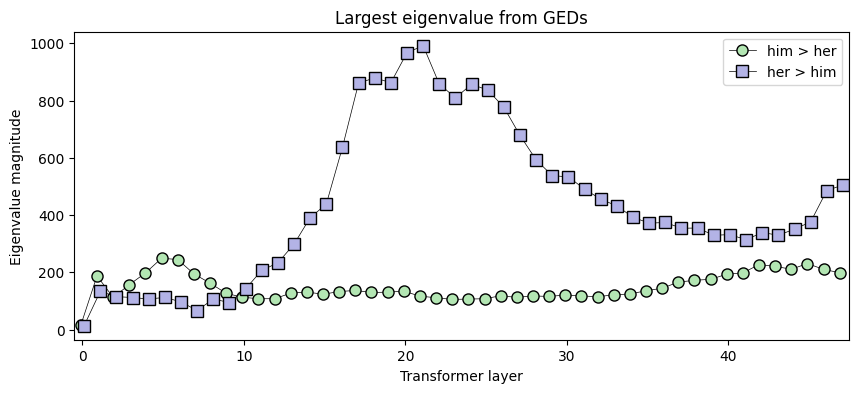

In [80]:
plt.figure(figsize=(10,4))

# top eigenvalues for him > her
plt.plot(np.arange(numLayers)-.1,ged_results[:,5,0],'ko-',markerfacecolor=[.7,.9,.7],
         linewidth=.5,markersize=8,label='him > her')

# top eigenvalues for her > him
plt.plot(np.arange(numLayers)+.1,ged_results[:,5,1],'ks-',markerfacecolor=[.7,.7,.9],
         linewidth=.5,markersize=8,label='her > him')

plt.legend()
plt.gca().set(xlabel='Transformer layer',ylabel='Eigenvalue magnitude',xlim=[-.5,numLayers-.5],
              title='Largest eigenvalue from GEDs')

plt.show()